# 01 - Data Ingestion and Target Definition

## Goal
Load the full monthly FRED macro panel, align and cache it locally, define an explicit inflation target, and run a first EDA pass.

This notebook is designed to run in two modes:
- online mode: fetch from FRED and refresh cache,
- offline mode: load local cached files when FRED is unavailable.

In [1]:
from pathlib import Path
import sys
import os
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.project_utils import ensure_project_dirs, seed_everything

seed_everything(42)
paths = ensure_project_dirs()
eda_dir = paths["results"] / "eda"
eda_dir.mkdir(parents=True, exist_ok=True)

pd.options.display.max_columns = 200
sns.set_theme(style="whitegrid")

print("Repo root:", ROOT)
print("Raw data dir:", paths["raw_data"])
print("Processed data dir:", paths["processed_data"])
print("EDA dir:", eda_dir)

Repo root: C:\Users\jijos\Desktop\261-Project
Raw data dir: C:\Users\jijos\Desktop\261-Project\data\raw
Processed data dir: C:\Users\jijos\Desktop\261-Project\data\processed
EDA dir: C:\Users\jijos\Desktop\261-Project\results\eda


## Target definition choice

We support two CPI inflation targets:

- `mom`: month-over-month CPI percent change.
- `yoy`: year-over-year CPI percent change.

Both are valid. For this class project, the default is `yoy` because it is smoother, less sensitive to one-month noise, and more standard in macro analysis.

Leakage-safe setup used below:
- first compute inflation at time `t` from CPI history up to `t`,
- then set the supervised target to inflation at `t + FORECAST_HORIZON` using a forward shift,
- features stay at time `t`, target is future by construction.

In [2]:
# Main config
TARGET_MODE = "yoy"           # options: "yoy" or "mom"
FORECAST_HORIZON = 1           # months ahead
START_DATE = "1985-01-01"
END_DATE = None                # use latest available if None
FORCE_REFRESH = False          # True -> pull from FRED and overwrite cache

if TARGET_MODE not in {"yoy", "mom"}:
    raise ValueError("TARGET_MODE must be 'yoy' or 'mom'")

print("TARGET_MODE:", TARGET_MODE)
print("FORECAST_HORIZON:", FORECAST_HORIZON)
print("START_DATE:", START_DATE)
print("END_DATE:", END_DATE)
print("FORCE_REFRESH:", FORCE_REFRESH)

TARGET_MODE: yoy
FORECAST_HORIZON: 1
START_DATE: 1985-01-01
END_DATE: None
FORCE_REFRESH: False


In [3]:
# Full macro series list used in this project
SERIES_CODES = {
    "CPI": "CPIAUCNS",
    "Unemployment": "UNRATE",
    "InterestRate": "FEDFUNDS",
    "M2": "M2SL",
    "Treasury10Y": "GS10",
    "OilPrice": "DCOILWTICO",
    "PPI": "PPIACO",
    "RetailSales": "RSXFS",
    "Sentiment": "UMCSENT",
    "Employment": "PAYEMS",
    "HousingStarts": "HOUST",
}

# Monthly collapse rule for each series
# Oil is daily so we use monthly mean; others use month-end last observation then align to month start index.
MONTHLY_AGG = {name: ("mean" if name == "OilPrice" else "last") for name in SERIES_CODES}

list(SERIES_CODES.items())[:3], MONTHLY_AGG["OilPrice"]

([('CPI', 'CPIAUCNS'),
  ('Unemployment', 'UNRATE'),
  ('InterestRate', 'FEDFUNDS')],
 'mean')

## Load from FRED with cache fallback

Caching policy:
- `data/raw/fred_macro_monthly_raw.csv`: aligned monthly macro panel without target columns.
- `data/processed/aligned_macro_target.csv`: final aligned dataset with target columns.
- `data/processed/target_definition_metadata.json`: exact target definition and run metadata.

If FRED fetch fails, the notebook falls back to local raw cache and prints a clear message.

In [4]:
raw_cache_path = paths["raw_data"] / "fred_macro_monthly_raw.csv"
processed_path = paths["processed_data"] / "aligned_macro_target.csv"
metadata_path = paths["processed_data"] / "target_definition_metadata.json"


def _to_monthly(series: pd.Series, how: str) -> pd.Series:
    s = series.dropna().copy()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()
    if how == "mean":
        out = s.resample("MS").mean()
    elif how == "last":
        out = s.resample("MS").last()
    else:
        raise ValueError(f"Unknown aggregation: {how}")
    return out


def _fetch_one_series_http(code: str, start_date: str, end_date: str | None) -> pd.Series:
    base = "https://fred.stlouisfed.org/graph/fredgraph.csv"
    url = f"{base}?id={code}"
    if start_date:
        url += f"&cosd={start_date}"
    if end_date:
        url += f"&coed={end_date}"

    tmp = pd.read_csv(url)
    if tmp.shape[1] < 2:
        raise RuntimeError(f"Unexpected FRED CSV format for {code}")

    tmp.columns = ["DATE", "VALUE"]
    tmp["DATE"] = pd.to_datetime(tmp["DATE"])
    tmp["VALUE"] = pd.to_numeric(tmp["VALUE"], errors="coerce")
    tmp = tmp.dropna(subset=["VALUE"]).set_index("DATE")
    return tmp["VALUE"]


def _fetch_from_fred(series_codes: dict[str, str], start_date: str, end_date: str | None) -> pd.DataFrame:
    monthly = {}

    # First try fredapi, then fallback to public CSV endpoint.
    try:
        from fredapi import Fred
        api_key = os.getenv("FRED_API_KEY")
        fred = Fred(api_key=api_key) if api_key else Fred()

        for name, code in series_codes.items():
            s = fred.get_series(code, observation_start=start_date, observation_end=end_date)
            monthly[name] = _to_monthly(s, MONTHLY_AGG[name])
    except Exception as fredapi_error:
        print("fredapi path unavailable. Falling back to FRED CSV endpoint.")
        print("Reason:", repr(fredapi_error))
        for name, code in series_codes.items():
            s = _fetch_one_series_http(code, start_date, end_date)
            monthly[name] = _to_monthly(s, MONTHLY_AGG[name])

    df = pd.DataFrame(monthly).sort_index()
    if start_date:
        df = df[df.index >= pd.to_datetime(start_date)]
    if end_date:
        df = df[df.index <= pd.to_datetime(end_date)]
    return df


if raw_cache_path.exists() and not FORCE_REFRESH:
    print(f"Loading cached monthly macro data from {raw_cache_path}")
    macro_df = pd.read_csv(raw_cache_path, index_col=0, parse_dates=True)
else:
    try:
        print("Fetching macro data from FRED...")
        macro_df = _fetch_from_fred(SERIES_CODES, START_DATE, END_DATE)
        macro_df.to_csv(raw_cache_path, index=True)
        print(f"Saved raw monthly macro cache -> {raw_cache_path}")
    except Exception as e:
        if raw_cache_path.exists():
            print("FRED fetch failed. Falling back to cached raw data.")
            print("Reason:", repr(e))
            macro_df = pd.read_csv(raw_cache_path, index_col=0, parse_dates=True)
        else:
            raise RuntimeError(
                "FRED fetch failed and no local cache was found at "
                f"{raw_cache_path}. Set FRED_API_KEY or provide cache."
            ) from e

macro_df = macro_df.sort_index()
macro_df.index = pd.to_datetime(macro_df.index)

print("Loaded macro_df shape:", macro_df.shape)
macro_df.head(3)


Loading cached monthly macro data from C:\Users\jijos\Desktop\261-Project\data\raw\fred_macro_monthly_raw.csv
Loaded macro_df shape: (496, 11)


,CPI,Unemployment,InterestRate,M2,Treasury10Y,OilPrice,PPI,RetailSales,Sentiment,Employment,HousingStarts
DATE,,,,,,,,,,,
1985-01-01,105.5,7.3,8.35,2332.4,11.38,NaN,103.4,NaN,96.0,96372.0,1711.0
1985-02-01,106.0,7.2,8.50,2354.1,11.51,NaN,103.3,NaN,93.7,96503.0,1632.0
1985-03-01,106.4,7.2,8.58,2366.2,11.86,NaN,103.1,NaN,93.7,96842.0,1800.0


In [5]:
# Basic monthly alignment checks before target creation
if macro_df.index.has_duplicates:
    raise ValueError("Duplicate timestamps found in macro_df index.")

month_start_aligned = bool((macro_df.index.day == 1).all())
inferred_freq = pd.infer_freq(macro_df.index)

print("Index inferred frequency:", inferred_freq)
print("All timestamps on month-start:", month_start_aligned)

if not month_start_aligned:
    raise ValueError("Index is not fully aligned to month-start timestamps.")

Index inferred frequency: MS
All timestamps on month-start: True


## Explicit, leakage-safe target construction

`CPI_t` is transformed into an inflation series at time `t`:
- `mom`: `100 * (CPI_t / CPI_{t-1} - 1)`
- `yoy`: `100 * (CPI_t / CPI_{t-12} - 1)`

Then the supervised target is shifted forward:
- `target_t = inflation_{t + FORECAST_HORIZON}`

So row `t` uses only information available at time `t` in features and predicts a future value.

In [6]:
def make_inflation_target(df: pd.DataFrame, target_mode: str, horizon: int) -> tuple[pd.DataFrame, str]:
    out = df.copy()
    cpi = out["CPI"]

    out["CPI_inflation_mom"] = cpi.pct_change(1) * 100.0
    out["CPI_inflation_yoy"] = cpi.pct_change(12) * 100.0

    current_col = "CPI_inflation_yoy" if target_mode == "yoy" else "CPI_inflation_mom"
    target_col = f"target_{target_mode}_t_plus_{horizon}"

    out[target_col] = out[current_col].shift(-horizon)

    # keep rows where both current inflation and target are defined
    out = out.dropna(subset=[current_col, target_col]).copy()
    return out, target_col


aligned_df, target_name = make_inflation_target(macro_df, TARGET_MODE, FORECAST_HORIZON)
aligned_df.to_csv(processed_path, index=True)

metadata = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "target_mode": TARGET_MODE,
    "forecast_horizon_months": FORECAST_HORIZON,
    "target_name": target_name,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "raw_cache_path": str(raw_cache_path.relative_to(ROOT)),
    "processed_dataset_path": str(processed_path.relative_to(ROOT)),
    "series_codes": SERIES_CODES,
    "monthly_aggregation": MONTHLY_AGG,
    "n_rows": int(aligned_df.shape[0]),
    "n_cols": int(aligned_df.shape[1]),
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved aligned dataset ->", processed_path)
print("Saved target metadata ->", metadata_path)
print("Target column ->", target_name)
aligned_df[["CPI", "CPI_inflation_mom", "CPI_inflation_yoy", target_name]].head(5)

Saved aligned dataset -> C:\Users\jijos\Desktop\261-Project\data\processed\aligned_macro_target.csv
Saved target metadata -> C:\Users\jijos\Desktop\261-Project\data\processed\target_definition_metadata.json
Target column -> target_yoy_t_plus_1


C:\Users\jijos\AppData\Local\Temp\ipykernel_17236\1529337811.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out["CPI_inflation_mom"] = cpi.pct_change(1) * 100.0
C:\Users\jijos\AppData\Local\Temp\ipykernel_17236\1529337811.py:6: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out["CPI_inflation_yoy"] = cpi.pct_change(12) * 100.0


,CPI,CPI_inflation_mom,CPI_inflation_yoy,target_yoy_t_plus_1
DATE,,,,
1986-01-01,109.6,0.274474,3.886256,3.113208
1986-02-01,109.3,-0.273723,3.113208,2.255639
1986-03-01,108.8,-0.457457,2.255639,1.590271
1986-04-01,108.6,-0.183824,1.590271,1.491146
1986-05-01,108.9,0.276243,1.491146,1.765799


## EDA

This section covers:
- date range,
- missing values,
- summary stats,
- target plot,
- compact correlation view,
- quick macro panel plot.

In [7]:
print("Date range:", aligned_df.index.min().date(), "to", aligned_df.index.max().date())
print("Rows, columns:", aligned_df.shape)

missing = aligned_df.isna().sum().sort_values(ascending=False)
print("Top missing-value counts (should be zero after drop step):")
print(missing.head(15))

print("Summary stats (first 12 columns):")
display(aligned_df.iloc[:, :12].describe().T)


Date range: 1986-01-01 to 2026-03-01
Rows, columns: (483, 14)
Top missing-value counts (should be zero after drop step):
RetailSales            73
CPI                     2
HousingStarts           2
Unemployment            1
M2                      1
PPI                     1
Sentiment               1
InterestRate            0
Treasury10Y             0
OilPrice                0
Employment              0
CPI_inflation_mom       0
CPI_inflation_yoy       0
target_yoy_t_plus_1     0
dtype: int64
Summary stats (first 12 columns):


,count,mean,std,min,25%,50%,75%,max
CPI,481.0,201.134898,56.881144,108.600000,154.400000,198.800000,238.343000,326.785000
Unemployment,482.0,5.699170,1.667882,3.400000,4.400000,5.400000,6.600000,14.800000
InterestRate,483.0,3.349337,2.648151,0.050000,0.405000,3.250000,5.330000,9.850000
M2,482.0,8922.209751,6087.782159,2502.100000,3651.375000,6742.400000,12582.550000,22667.300000
Treasury10Y,483.0,4.658033,2.218379,0.620000,2.785000,4.350000,6.275000,9.520000
OilPrice,483.0,48.240248,29.330496,11.347273,20.241250,42.867619,71.211472,133.880000
PPI,482.0,165.568820,47.573041,99.300000,124.625000,163.350000,200.025000,280.251000
RetailSales,410.0,340492.458537,133212.176340,142120.000000,243154.000000,320308.500000,409128.750000,638224.000000
Sentiment,482.0,85.184440,13.613219,50.000000,75.350000,89.000000,94.775000,112.000000
Employment,483.0,131013.383023,15941.111414,98732.000000,118531.500000,132125.000000,142200.000000,158637.000000


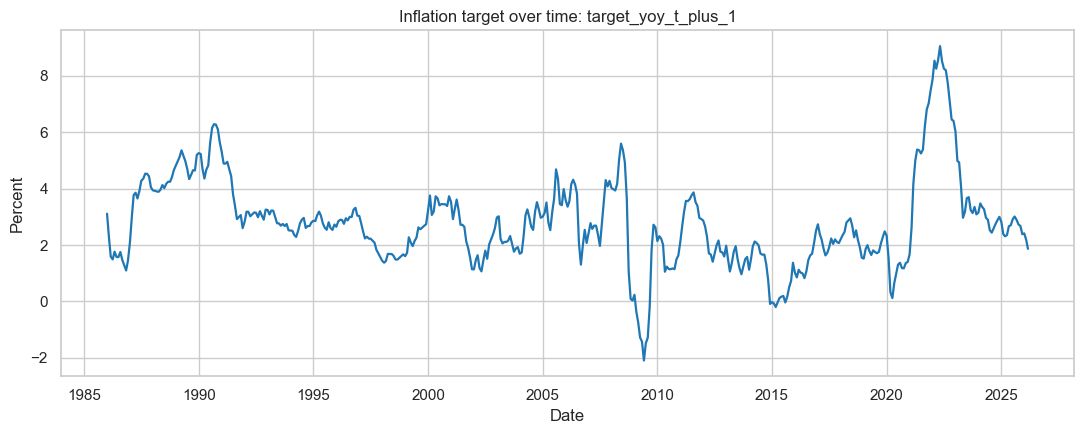

Saved: C:\Users\jijos\Desktop\261-Project\results\eda\target_series.png


In [8]:
# Target time series plot
plt.figure(figsize=(11, 4.5))
plt.plot(aligned_df.index, aligned_df[target_name], color="#1f77b4", linewidth=1.6)
plt.title(f"Inflation target over time: {target_name}")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.tight_layout()

target_fig = eda_dir / "target_series.png"
plt.savefig(target_fig, dpi=140)
plt.show()
print("Saved:", target_fig)

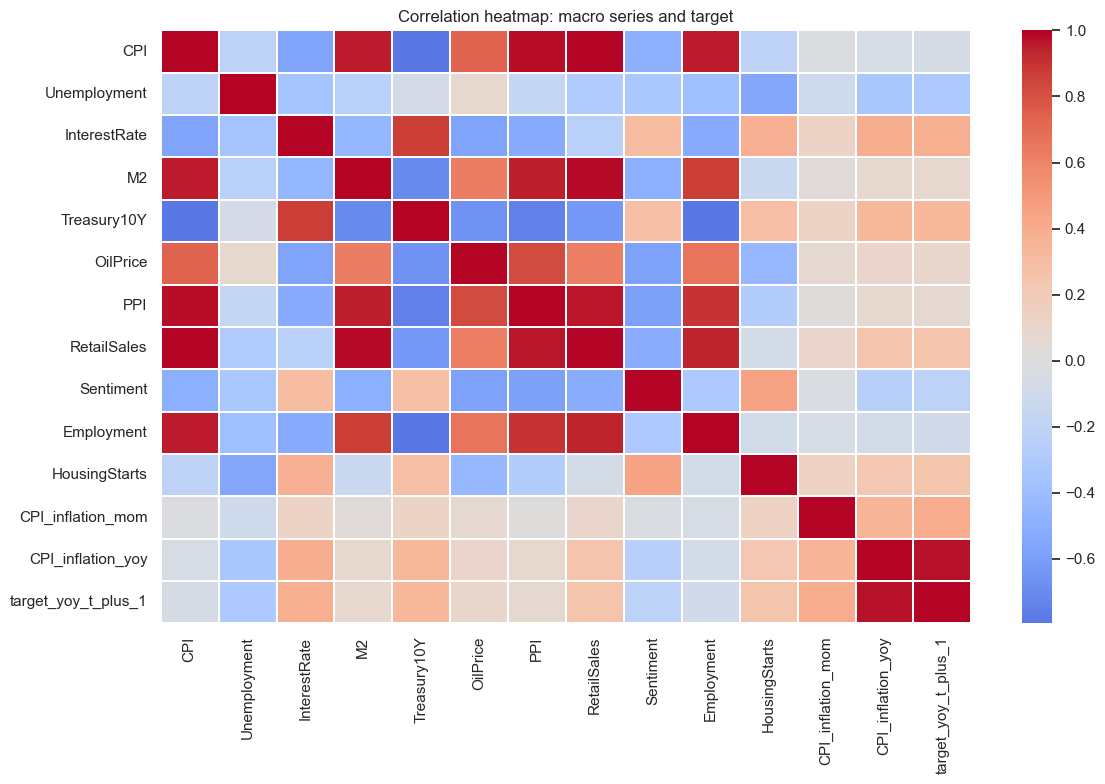

Saved: C:\Users\jijos\Desktop\261-Project\results\eda\correlation_heatmap.png
Top absolute correlations with target:
CPI_inflation_yoy    0.969404
CPI_inflation_mom    0.397658
InterestRate         0.382981
Treasury10Y          0.329543
Unemployment         0.314771
RetailSales          0.252793
HousingStarts        0.248531
Sentiment            0.224518
Name: target_yoy_t_plus_1, dtype: float64


In [9]:
# Correlation heatmap (macro + target)
corr_cols = list(SERIES_CODES.keys()) + ["CPI_inflation_mom", "CPI_inflation_yoy", target_name]
corr_df = aligned_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation heatmap: macro series and target")
plt.tight_layout()

corr_fig = eda_dir / "correlation_heatmap.png"
plt.savefig(corr_fig, dpi=140)
plt.show()
print("Saved:", corr_fig)

print("Top absolute correlations with target:")
print(corr_df[target_name].drop(target_name).abs().sort_values(ascending=False).head(8))


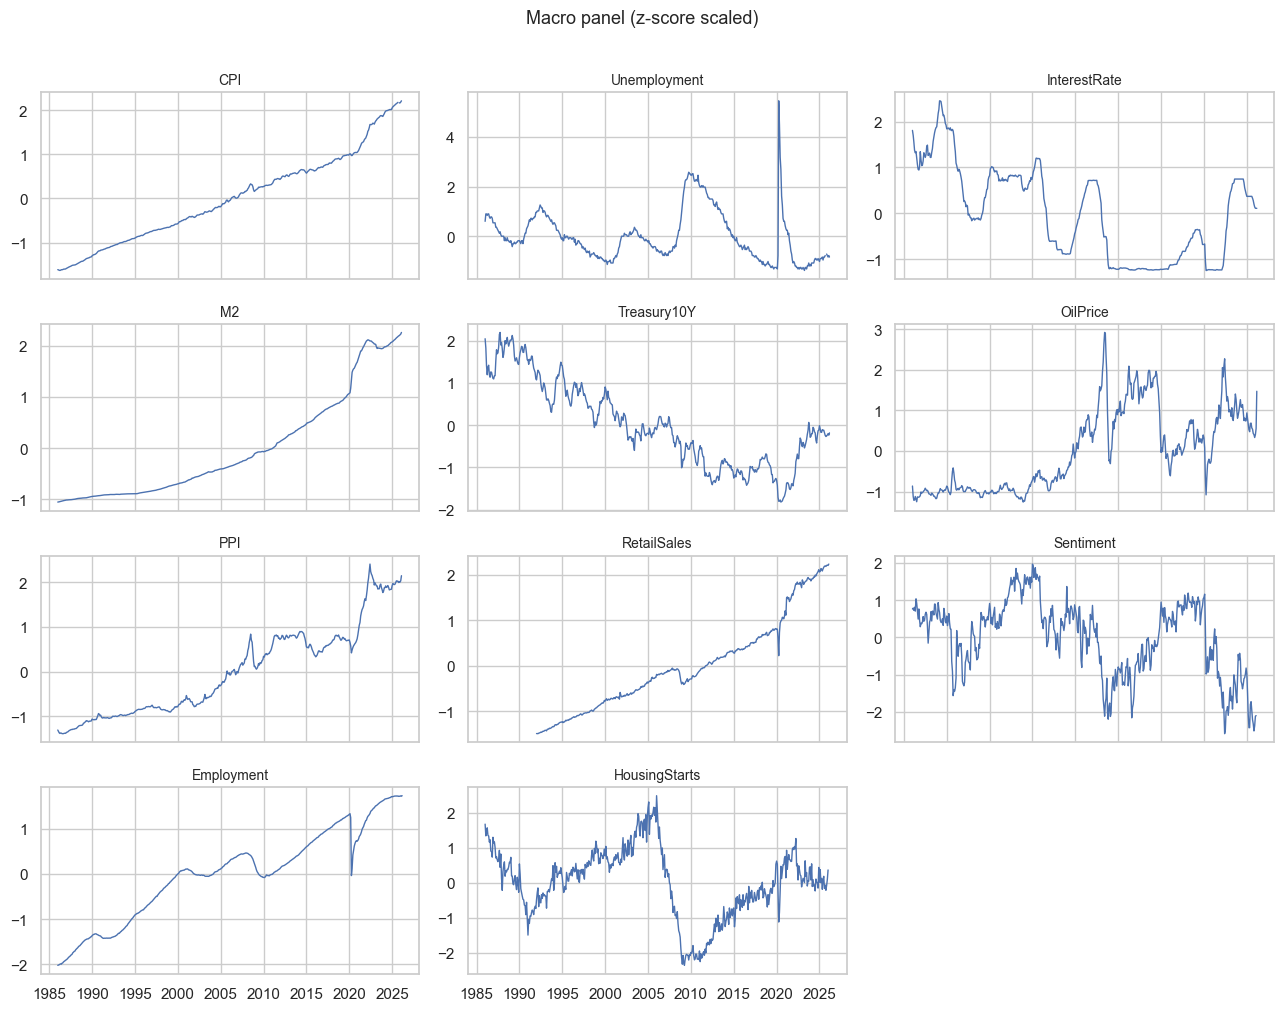

Saved: C:\Users\jijos\Desktop\261-Project\results\eda\macro_panel_zscore.png


In [10]:
# Quick panel of raw macro series (normalized for visual comparability)
z = (aligned_df[list(SERIES_CODES.keys())] - aligned_df[list(SERIES_CODES.keys())].mean()) / aligned_df[list(SERIES_CODES.keys())].std()

fig, axes = plt.subplots(4, 3, figsize=(13, 10), sharex=True)
axes = axes.flatten()

for i, col in enumerate(z.columns):
    axes[i].plot(z.index, z[col], linewidth=1.0)
    axes[i].set_title(col, fontsize=10)

for j in range(len(z.columns), len(axes)):
    axes[j].axis("off")

fig.suptitle("Macro panel (z-score scaled)", y=1.01, fontsize=13)
fig.tight_layout()

panel_fig = eda_dir / "macro_panel_zscore.png"
fig.savefig(panel_fig, dpi=140, bbox_inches="tight")
plt.show()
print("Saved:", panel_fig)

## Final verification checks

Required checks for this notebook:
- final dataframe shape, columns, and target name,
- no duplicate timestamps,
- monthly alignment correctness.

In [11]:
print("Final dataframe shape:", aligned_df.shape)
print("Final columns:", list(aligned_df.columns))
print("Final target name:", target_name)

dup_count = int(aligned_df.index.duplicated().sum())
print("Duplicate timestamp count:", dup_count)

monthly_ok = bool((aligned_df.index.day == 1).all())
inferred = pd.infer_freq(aligned_df.index)
print("Monthly alignment day==1:", monthly_ok)
print("Inferred frequency:", inferred)

if dup_count != 0:
    raise AssertionError("Duplicate timestamps detected in final dataset.")
if not monthly_ok:
    raise AssertionError("Final dataset index is not month-start aligned.")

Final dataframe shape: (483, 14)
Final columns: ['CPI', 'Unemployment', 'InterestRate', 'M2', 'Treasury10Y', 'OilPrice', 'PPI', 'RetailSales', 'Sentiment', 'Employment', 'HousingStarts', 'CPI_inflation_mom', 'CPI_inflation_yoy', 'target_yoy_t_plus_1']
Final target name: target_yoy_t_plus_1
Duplicate timestamp count: 0
Monthly alignment day==1: True
Inferred frequency: MS
